In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/Marutichilme/superstore-sales-analysis/main/superstore.csv"

df = pd.read_csv(url)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [2]:
# Basic information about the dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows: 10800
Columns: 21

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID            object
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object


In [3]:
# Check missing values

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,806
Ship Date,806
Ship Mode,806
Customer ID,806
Customer Name,806
Segment,806
Country,806
City,806


In [4]:
# Basic statistical summary

df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# Make a copy before cleaning
df_clean = df.copy()

# Convert dates to datetime
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

# Check missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

# Remove the unnecessary index column
if "index" in df_clean.columns:
    df_clean = df_clean.drop(columns=["index"])

# Postal Code is missing for some records.
# Keep those rows because Postal Code isn't essential for our main analysis.
df_clean["Postal Code"] = df_clean["Postal Code"].fillna(0)

print("\nDataset shape after cleaning:", df_clean.shape)

Missing values before cleaning:
Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

Dataset shape after cleaning: (10800, 21)


In [6]:
# Check duplicates

print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 504


In [7]:
# Check the cleaned dataset

df_clean.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [8]:
# Sales and Profit by Category

category_analysis = (
    df_clean.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

category_analysis

,Total_Sales,Total_Profit,Total_Quantity
Category,,,
Technology,836154.0330,145454.9481,6939.0
Furniture,741999.7953,18451.2728,8028.0
Office Supplies,719047.0320,122490.8008,22906.0


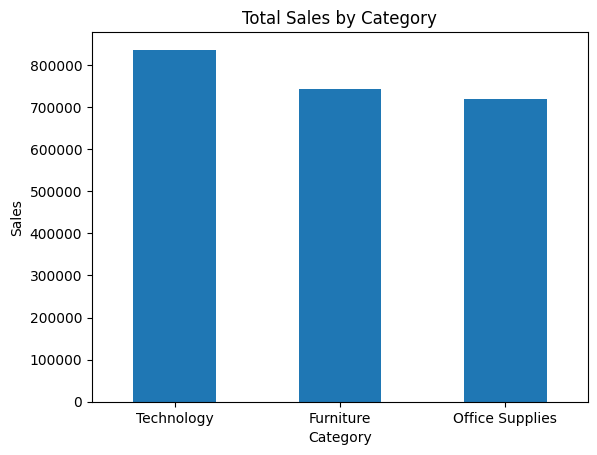

In [9]:
import matplotlib.pyplot as plt

category_analysis["Total_Sales"].plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [10]:
category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"] /
    category_analysis["Total_Sales"] * 100
).round(2)

category_analysis

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Category,,,,
Technology,836154.0330,145454.9481,6939.0,17.40
Furniture,741999.7953,18451.2728,8028.0,2.49
Office Supplies,719047.0320,122490.8008,22906.0,17.04


In [11]:
# Profitability by Sub-Category

subcategory_analysis = (
    df_clean.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Profit")
)

subcategory_analysis

,Total_Sales,Total_Profit,Total_Quantity
Sub-Category,,,
Tables,206965.5320,-17725.4811,1241.0
Bookcases,114879.9963,-3472.5560,868.0
Supplies,46673.5380,-1189.0995,647.0
Fasteners,3024.2800,949.5182,914.0
Machines,189238.6310,3384.7569,440.0
Labels,12486.3120,5546.2540,1400.0
Art,27118.7920,6527.7870,3000.0
Envelopes,16476.4020,6964.1767,906.0
Furnishings,91705.1640,13059.1436,3563.0


In [12]:
# Calculate profit margin

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Total_Profit"] /
    subcategory_analysis["Total_Sales"] * 100
).round(2)

subcategory_analysis

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241.0,-8.56
Bookcases,114879.9963,-3472.5560,868.0,-3.02
Supplies,46673.5380,-1189.0995,647.0,-2.55
Fasteners,3024.2800,949.5182,914.0,31.40
Machines,189238.6310,3384.7569,440.0,1.79
Labels,12486.3120,5546.2540,1400.0,44.42
Art,27118.7920,6527.7870,3000.0,24.07
Envelopes,16476.4020,6964.1767,906.0,42.27
Furnishings,91705.1640,13059.1436,3563.0,14.24


In [13]:
discount_analysis = (
    df_clean.groupby("Discount")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
)

discount_analysis["Profit_Margin_%"] = (
    discount_analysis["Total_Profit"] /
    discount_analysis["Total_Sales"] * 100
).round(2)

discount_analysis

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Discount,,,,
0.00,1.087908e+06,320987.6032,18267.0,29.51
0.10,5.436935e+04,9029.1770,373.0,16.61
0.15,2.755852e+04,1418.9915,198.0,5.15
0.20,7.645944e+05,90337.3060,13660.0,11.82
0.30,1.032267e+05,-10369.2774,849.0,-10.05
0.32,1.449346e+04,-2391.1377,105.0,-16.50
0.40,1.164178e+05,-23057.0504,786.0,-19.81
0.45,5.484974e+03,-2493.1111,45.0,-45.45
0.50,5.891854e+04,-20506.4281,241.0,-34.80


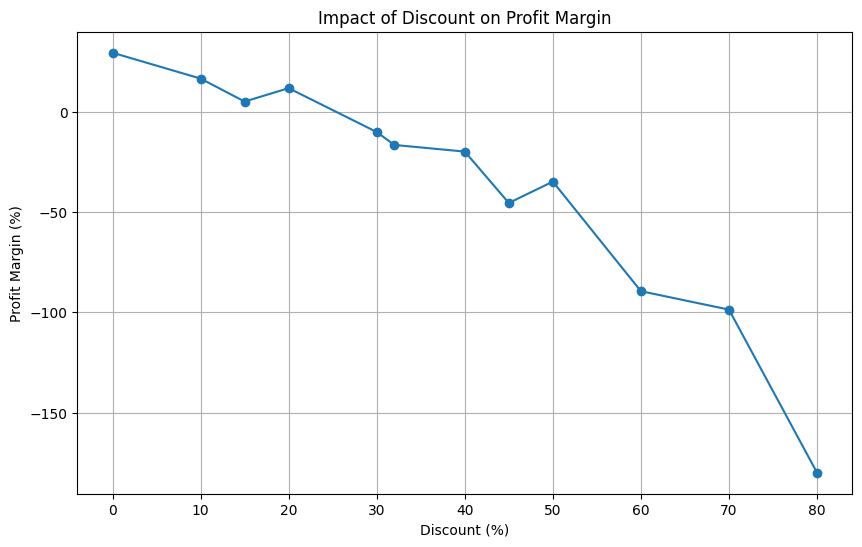

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    discount_analysis.index * 100,
    discount_analysis["Profit_Margin_%"],
    marker="o"
)

plt.title("Impact of Discount on Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.grid(True)

plt.show()

In [15]:
loss_products = (
    df_clean.groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean")
    )
    .sort_values("Total_Profit")
)

loss_products.head(10)

,Total_Sales,Total_Profit,Average_Discount
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,0.533333
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,0.400000
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,0.500000
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,0.280000
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,0.350000
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,0.450000
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,0.500000
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,0.100000
Balt Solid Wood Round Tables,6518.754,-1201.0581,0.200000


In [16]:
# Monthly Sales and Profit Trend

df_clean["Year_Month"] = df_clean["Order Date"].dt.to_period("M")

monthly_analysis = (
    df_clean.groupby("Year_Month")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

monthly_analysis

,Total_Sales,Total_Profit
Year_Month,,
2015-01,14236.8950,2450.1907
2015-02,4519.8920,862.3084
2015-03,55691.0090,498.7299
2015-04,28295.3450,3488.8352
2015-05,23648.2870,2738.7096
2015-06,34595.1276,4976.5244
2015-07,33946.3930,-841.4826
2015-08,27909.4685,5318.1050
2015-09,81777.3508,8328.0994


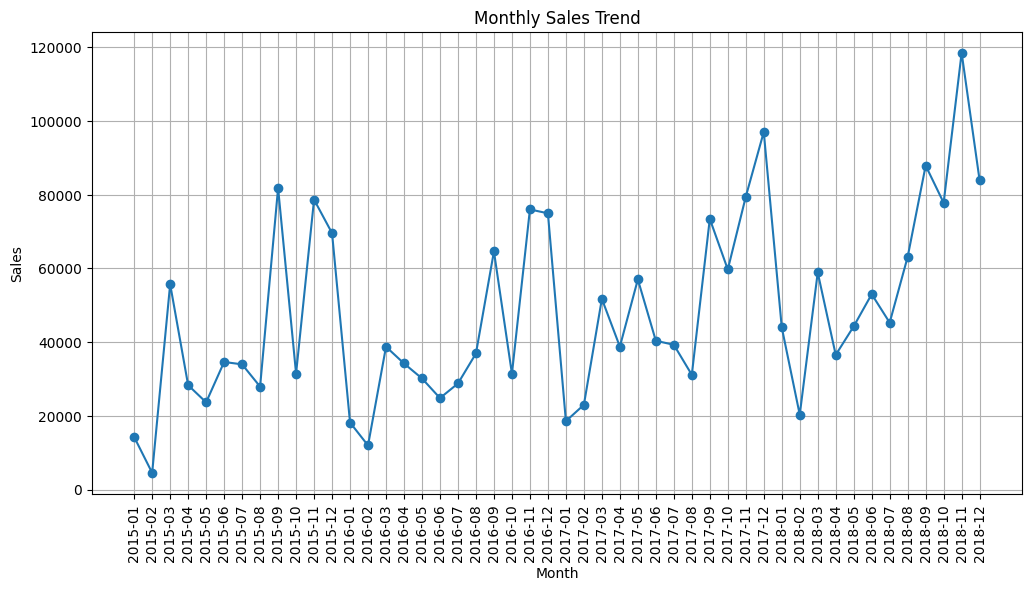

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis.index.astype(str),
    monthly_analysis["Total_Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [18]:
# Yearly Sales and Profit

yearly_analysis = (
    df_clean.groupby(df_clean["Order Date"].dt.year)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

yearly_analysis

,Total_Sales,Total_Profit
Order Date,,
2015.0,484247.4981,49543.9741
2016.0,470532.5090,61618.6037
2017.0,609205.5980,81795.1743
2018.0,733215.2552,93439.2696


In [19]:
# Calculate yearly profit margin

yearly_analysis["Profit_Margin_%"] = (
    yearly_analysis["Total_Profit"] /
    yearly_analysis["Total_Sales"] * 100
).round(2)

yearly_analysis

,Total_Sales,Total_Profit,Profit_Margin_%
Order Date,,,
2015.0,484247.4981,49543.9741,10.23
2016.0,470532.5090,61618.6037,13.10
2017.0,609205.5980,81795.1743,13.43
2018.0,733215.2552,93439.2696,12.74


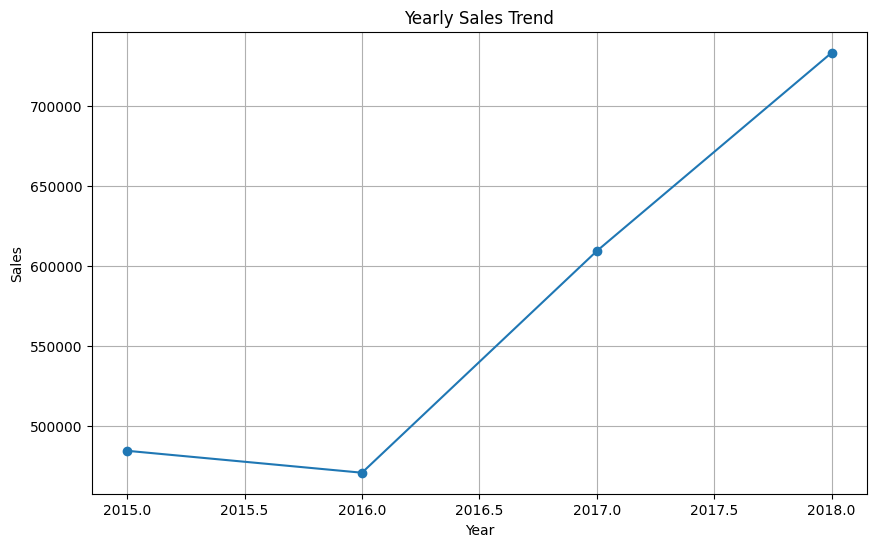

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_analysis.index,
    yearly_analysis["Total_Sales"],
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [21]:
# Sales and Profit by Region

region_analysis = (
    df_clean.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

region_analysis

,Total_Sales,Total_Profit,Total_Quantity
Region,,,
West,725457.8245,108418.4489,12266.0
East,678781.2400,91522.7800,10618.0
Central,501239.8908,39706.3625,8780.0
South,391721.9050,46749.4303,6209.0


In [22]:
# Calculate profit margin

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"] /
    region_analysis["Total_Sales"] * 100
).round(2)

region_analysis

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Region,,,,
West,725457.8245,108418.4489,12266.0,14.94
East,678781.2400,91522.7800,10618.0,13.48
Central,501239.8908,39706.3625,8780.0,7.92
South,391721.9050,46749.4303,6209.0,11.93


In [23]:
# Customer Sales and Profit Analysis

customer_analysis = (
    df_clean.groupby(["Customer ID", "Customer Name"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

customer_analysis.head(10)



,,Total_Sales,Total_Profit,Total_Orders
Customer ID,Customer Name,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5
TC-20980,Tamara Chand,19052.218,8981.3239,5
RB-19360,Raymond Buch,15117.339,6976.0959,6
TA-21385,Tom Ashbrook,14595.620,4703.7883,4
AB-10105,Adrian Barton,14473.571,5444.8055,10
KL-16645,Ken Lonsdale,14175.229,806.8550,12
SC-20095,Sanjit Chand,14142.334,5757.4119,9
HL-15040,Hunter Lopez,12873.298,5622.4292,6
SE-20110,Sanjit Engle,12209.438,2650.6769,11


In [24]:
# Top 10 Most Profitable Customers

top_profit_customers = customer_analysis.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

top_profit_customers

,,Total_Sales,Total_Profit,Total_Orders
Customer ID,Customer Name,,,
TC-20980,Tamara Chand,19052.218,8981.3239,5
RB-19360,Raymond Buch,15117.339,6976.0959,6
SC-20095,Sanjit Chand,14142.334,5757.4119,9
HL-15040,Hunter Lopez,12873.298,5622.4292,6
AB-10105,Adrian Barton,14473.571,5444.8055,10
TA-21385,Tom Ashbrook,14595.620,4703.7883,4
CM-12385,Christopher Martinez,8954.020,3899.8904,4
KD-16495,Keith Dawkins,8181.256,3038.6254,12
AR-10540,Andy Reiter,6608.448,2884.6208,6


In [25]:
# Customers with high sales but negative profit

loss_customers = customer_analysis[
    customer_analysis["Total_Profit"] < 0
].sort_values(
    "Total_Sales",
    ascending=False
)

loss_customers.head(10)

,,Total_Sales,Total_Profit,Total_Orders
Customer ID,Customer Name,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5
BM-11140,Becky Martin,11789.630,-1659.9581,4
GT-14635,Grant Thornton,9351.212,-4108.6589,3
PF-19120,Peter Fuller,9062.864,-614.2943,4
NF-18385,Natalie Fritzler,8322.826,-1695.9714,7
SB-20290,Sean Braxton,8057.891,-2082.7451,7
ZC-21910,Zuschuss Carroll,8025.707,-1032.1490,13
JH-15985,Joseph Holt,7954.998,-644.6982,6
JA-15970,Joseph Airdo,6491.026,-819.4217,8


In [26]:
# Top 10 Most Profitable Customers

top_profit_customers = (
    customer_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_profit_customers

,,Total_Sales,Total_Profit,Total_Orders
Customer ID,Customer Name,,,
TC-20980,Tamara Chand,19052.218,8981.3239,5
RB-19360,Raymond Buch,15117.339,6976.0959,6
SC-20095,Sanjit Chand,14142.334,5757.4119,9
HL-15040,Hunter Lopez,12873.298,5622.4292,6
AB-10105,Adrian Barton,14473.571,5444.8055,10
TA-21385,Tom Ashbrook,14595.620,4703.7883,4
CM-12385,Christopher Martinez,8954.020,3899.8904,4
KD-16495,Keith Dawkins,8181.256,3038.6254,12
AR-10540,Andy Reiter,6608.448,2884.6208,6


In [27]:
top_profit_customers["Profit_Margin_%"] = (
    top_profit_customers["Total_Profit"] /
    top_profit_customers["Total_Sales"] * 100
).round(2)

top_profit_customers

,,Total_Sales,Total_Profit,Total_Orders,Profit_Margin_%
Customer ID,Customer Name,,,,
TC-20980,Tamara Chand,19052.218,8981.3239,5,47.14
RB-19360,Raymond Buch,15117.339,6976.0959,6,46.15
SC-20095,Sanjit Chand,14142.334,5757.4119,9,40.71
HL-15040,Hunter Lopez,12873.298,5622.4292,6,43.68
AB-10105,Adrian Barton,14473.571,5444.8055,10,37.62
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,32.23
CM-12385,Christopher Martinez,8954.020,3899.8904,4,43.55
KD-16495,Keith Dawkins,8181.256,3038.6254,12,37.14
AR-10540,Andy Reiter,6608.448,2884.6208,6,43.65


In [28]:
# Regional Performance

region_analysis = (
    df_clean.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Total_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"] /
    region_analysis["Total_Sales"] * 100
).round(2)

region_analysis

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
Region,,,,,
West,725457.8245,108418.4489,12266.0,1611,14.94
East,678781.2400,91522.7800,10618.0,1401,13.48
Central,501239.8908,39706.3625,8780.0,1175,7.92
South,391721.9050,46749.4303,6209.0,822,11.93


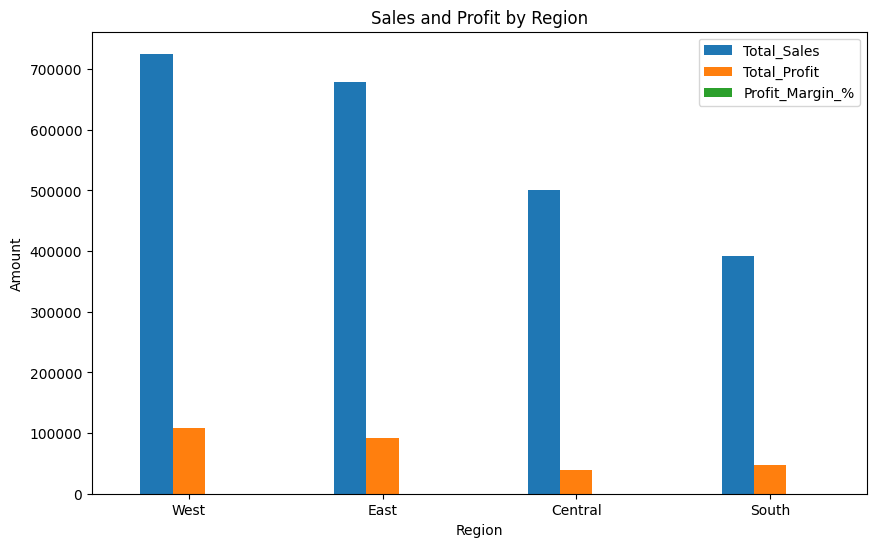

In [29]:
# Sales and Profit by Region

region_analysis[[
    "Total_Sales",
    "Total_Profit",
    "Profit_Margin_%"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

In [30]:
region_analysis

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit_Margin_%
Region,,,,,
West,725457.8245,108418.4489,12266.0,1611,14.94
East,678781.2400,91522.7800,10618.0,1401,13.48
Central,501239.8908,39706.3625,8780.0,1175,7.92
South,391721.9050,46749.4303,6209.0,822,11.93


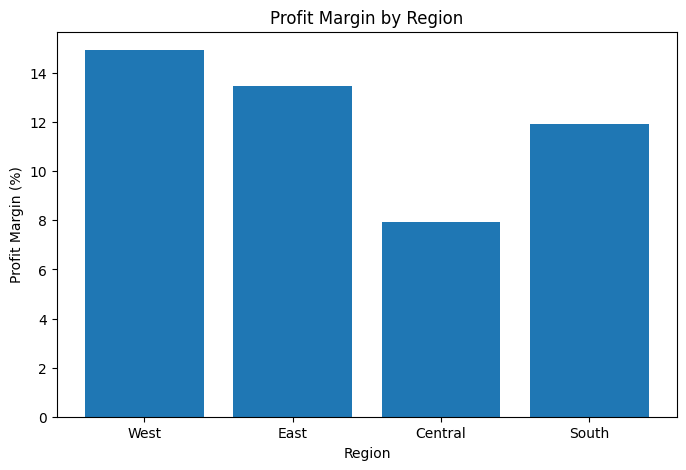

In [31]:
# Profit Margin by Region

plt.figure(figsize=(8, 5))

plt.bar(
    region_analysis.index,
    region_analysis["Profit_Margin_%"]
)

plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")

plt.show()

In [32]:
# Display regional performance clearly

region_analysis[[
    "Total_Sales",
    "Total_Profit",
    "Profit_Margin_%"
]].round(2)

,Total_Sales,Total_Profit,Profit_Margin_%
Region,,,
West,725457.82,108418.45,14.94
East,678781.24,91522.78,13.48
Central,501239.89,39706.36,7.92
South,391721.90,46749.43,11.93


In [33]:
# Top 10 Products by Sales

top_products_sales = (
    df_clean.groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_products_sales

,Total_Sales,Total_Profit,Total_Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20.0
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31.0
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6.0
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39.0
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37.0
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48.0
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38.0
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12.0
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27.0


In [34]:
# Top 10 Products by Profit

top_products_profit = (
    df_clean.groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_products_profit

,Total_Sales,Total_Profit,Total_Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20.0
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390,31.0
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38.0
Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19.0
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766,12.0
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11.0
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11.0
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820,24.0
Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13.0
